In [1]:
!pip install pandas numpy nltk scikit-learn matplotlib

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
df = pd.read_csv("Banking_Complaints.csv")

In [4]:
print("Dataset loaded successfully!")

print("\nFirst 10 records:")
print(df.head(10))

print("\nDataset shape:")
print(df.shape)

Dataset loaded successfully!

First 10 records:
  Complaint_ID                                     Complaint_Text  \
0         C001  My money was deducted from my account but the ...   
1         C002  The amount was debited but the receiver did no...   
2         C003                My online transfer is still pending   
3         C004       I was charged twice for the same transaction   
4         C005  The cash was not received even though the ATM ...   
5         C006        My account was charged for a failed payment   
6         C007  The bank transfer was unsuccessful but money w...   
7         C008  My transaction has been pending for several hours   
8         C009       Why was money deducted during my transaction   
9         C010  The transferred amount has not reached the ben...   

            Category  
0  Transaction Issue  
1  Transaction Issue  
2  Transaction Issue  
3  Transaction Issue  
4  Transaction Issue  
5  Transaction Issue  
6  Transaction Issue  
7  Trans

In [5]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Complaint_ID      0
Complaint_Text    0
Category          0
dtype: int64


In [6]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

df['Cleaned_Text'] = df['Complaint_Text'].apply(preprocess_text)

print(df[['Complaint_Text', 'Cleaned_Text']].head(10))

                                      Complaint_Text  \
0  My money was deducted from my account but the ...   
1  The amount was debited but the receiver did no...   
2                My online transfer is still pending   
3       I was charged twice for the same transaction   
4  The cash was not received even though the ATM ...   
5        My account was charged for a failed payment   
6  The bank transfer was unsuccessful but money w...   
7  My transaction has been pending for several hours   
8       Why was money deducted during my transaction   
9  The transferred amount has not reached the ben...   

                                    Cleaned_Text  
0      money deducted account transaction failed  
1          amount debited receiver receive money  
2                  online transfer still pending  
3                      charged twice transaction  
4  cash received even though atm deducted amount  
5                 account charged failed payment  
6      bank transfer unsuc

Category
Transaction Issue     12
Loan Issue            12
Online Banking        12
Account Management    12
Card Issue            12
Name: count, dtype: int64


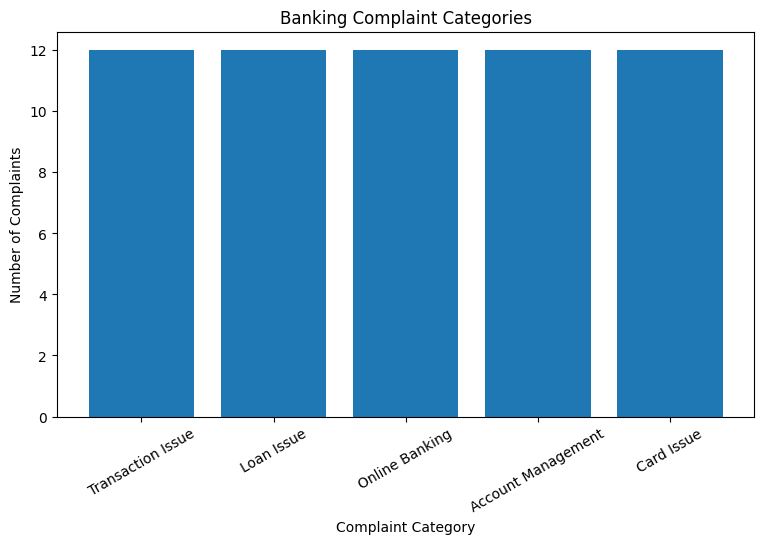

In [7]:
print(df['Category'].value_counts())
category_counts = df['Category'].value_counts()

plt.figure(figsize=(9,5))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.title("Banking Complaint Categories")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=30)

plt.show()

In [8]:
vectorizer = TfidfVectorizer(
    stop_words='english'
)

X = vectorizer.fit_transform(df['Cleaned_Text'])

y = df['Category']

print("TF-IDF matrix shape:")
print(X.shape)

TF-IDF matrix shape:
(60, 106)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 48
Testing records: 12


In [10]:
model = MultinomialNB()

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [11]:
y_pred = model.predict(X_test)

print("Predicted Categories:")
print(y_pred)

Predicted Categories:
['Transaction Issue' 'Online Banking' 'Online Banking' 'Loan Issue'
 'Account Management' 'Card Issue' 'Transaction Issue'
 'Account Management' 'Loan Issue' 'Card Issue' 'Transaction Issue'
 'Account Management']


In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

Model Accuracy: 0.8333333333333334
Accuracy Percentage: 83.33333333333334


In [13]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Classification Report:
                    precision    recall  f1-score   support

Account Management       0.67      0.67      0.67         3
        Card Issue       1.00      1.00      1.00         2
        Loan Issue       1.00      1.00      1.00         2
    Online Banking       1.00      0.67      0.80         3
 Transaction Issue       0.67      1.00      0.80         2

          accuracy                           0.83        12
         macro avg       0.87      0.87      0.85        12
      weighted avg       0.86      0.83      0.83        12



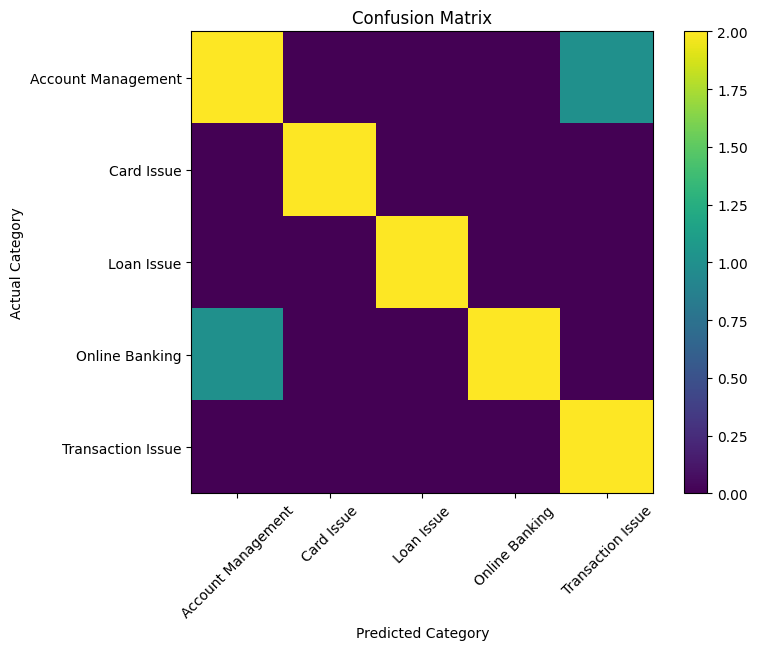

In [14]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.xticks(
    range(len(model.classes_)),
    model.classes_,
    rotation=45
)

plt.yticks(
    range(len(model.classes_)),
    model.classes_
)

plt.colorbar()

plt.show()

In [15]:
new_complaints = [
    "My debit card is not working",
    "I cannot login to my mobile banking application",
    "My loan application is still pending",
    "Money was deducted but the transaction failed",
    "I want to change my registered phone number"
]

new_complaints_cleaned = [
    preprocess_text(text)
    for text in new_complaints
]

new_complaints_tfidf = vectorizer.transform(
    new_complaints_cleaned
)

predictions = model.predict(
    new_complaints_tfidf
)

for complaint, category in zip(
    new_complaints,
    predictions
):
    print("\nComplaint:", complaint)
    print("Predicted Category:", category)


Complaint: My debit card is not working
Predicted Category: Card Issue

Complaint: I cannot login to my mobile banking application
Predicted Category: Online Banking

Complaint: My loan application is still pending
Predicted Category: Loan Issue

Complaint: Money was deducted but the transaction failed
Predicted Category: Transaction Issue

Complaint: I want to change my registered phone number
Predicted Category: Account Management


In [16]:
from collections import Counter

all_text = ' '.join(
    df['Cleaned_Text']
)

words = all_text.split()

word_counts = Counter(words)

common_words = word_counts.most_common(15)

print("Most Frequent Banking Issues/Terms:")

for word, count in common_words:
    print(word, ":", count)

Most Frequent Banking Issues/Terms:
account : 12
loan : 12
card : 12
banking : 9
bank : 8
transaction : 7
amount : 7
need : 7
deducted : 6
application : 6
want : 6
money : 5
online : 5
cannot : 5
mobile : 5


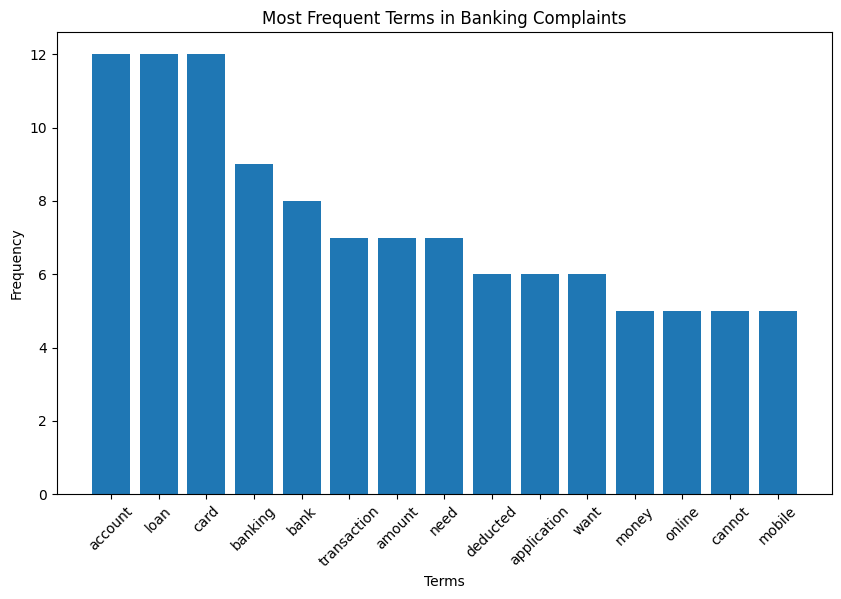

In [17]:
common_df = pd.DataFrame(
    common_words,
    columns=['Word', 'Frequency']
)

plt.figure(figsize=(10,6))

plt.bar(
    common_df['Word'],
    common_df['Frequency']
)

plt.title("Most Frequent Terms in Banking Complaints")
plt.xlabel("Terms")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

Complaint Analysis:
Category
Transaction Issue     12
Loan Issue            12
Online Banking        12
Account Management    12
Card Issue            12
Name: count, dtype: int64


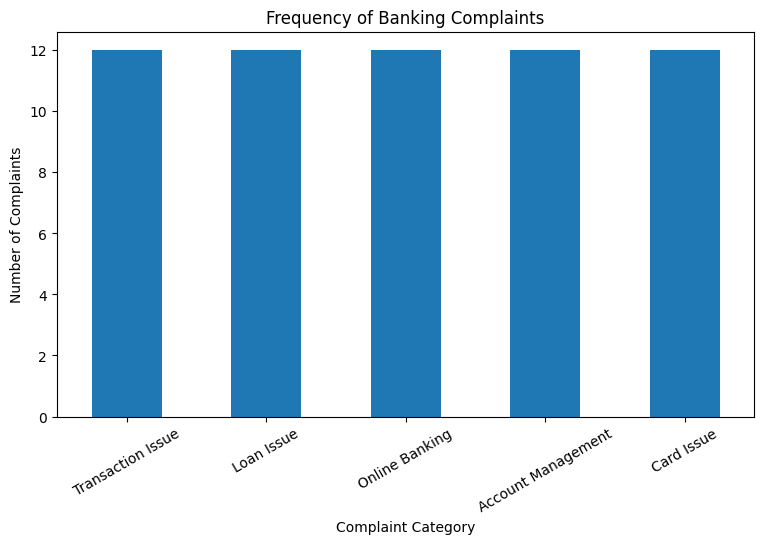

In [18]:
category_counts = df['Category'].value_counts()

print("Complaint Analysis:")
print(category_counts)
plt.figure(figsize=(9,5))

category_counts.plot(kind='bar')

plt.title("Frequency of Banking Complaints")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=30)

plt.show()

In [19]:
total_complaints = len(df)

most_common_category = df['Category'].value_counts().idxmax()

most_common_count = df['Category'].value_counts().max()

print("=" * 50)
print("       BANKING COMPLAINT ANALYTICAL REPORT")
print("=" * 50)

print("\nTotal Complaints:", total_complaints)

print("\nComplaint Categories:")
print(df['Category'].value_counts())

print("\nMost Frequent Complaint Category:")
print(most_common_category)

print("\nNumber of Complaints in This Category:")
print(most_common_count)

print("\nModel Accuracy:")
print(round(accuracy * 100, 2), "%")

print("\nKey Findings:")

for category, count in category_counts.items():
    print("-", category, ":", count, "complaints")

print("\nRecommendations:")

print("1. Improve transaction processing and failure resolution.")

print("2. Provide faster support for loan-related complaints.")

print("3. Improve online banking application reliability.")

print("4. Provide easier account management services.")

print("5. Improve card replacement and card support services.")

print("\nConclusion:")
print("NLP can help banks automatically categorize customer complaints,")
print("identify frequent banking issues, and improve customer service efficiency.")

print("=" * 50)

       BANKING COMPLAINT ANALYTICAL REPORT

Total Complaints: 60

Complaint Categories:
Category
Transaction Issue     12
Loan Issue            12
Online Banking        12
Account Management    12
Card Issue            12
Name: count, dtype: int64

Most Frequent Complaint Category:
Transaction Issue

Number of Complaints in This Category:
12

Model Accuracy:
83.33 %

Key Findings:
- Transaction Issue : 12 complaints
- Loan Issue : 12 complaints
- Online Banking : 12 complaints
- Account Management : 12 complaints
- Card Issue : 12 complaints

Recommendations:
1. Improve transaction processing and failure resolution.
2. Provide faster support for loan-related complaints.
3. Improve online banking application reliability.
4. Provide easier account management services.
5. Improve card replacement and card support services.

Conclusion:
NLP can help banks automatically categorize customer complaints,
identify frequent banking issues, and improve customer service efficiency.
